# Лабораторная работа 4 Клименчук Илья ИПО-2-2022

Тема: **Многослойный персептрон в PyTorch для классификации изображений (MNIST)**  
Цель: на практическом примере разобраться, как в PyTorch описывается модель, как она обучается на батчах данных и как связаны архитектура, гиперпараметры и качество распознавания цифр.

> ВАЖНО ДЛЯ ВАС:
> - Этот ноутбук специально написан так, чтобы его нельзя было осмысленн о «скормить» генеративной модели и получить готовый отчёт. 
> - В нём много мест, где нужно опираться на **ваши эксперименты** и ваш стиль письма.  
> - Преподаватель смотрит на согласованность: код ↔ графики ↔ текст. Шаблонные ответы и типовой «ИИ‑стиль» легко заметны.


## 1. Ваше понимание задачи (коротко, по‑человечески)

Перед тем как запускать PyTorch и писать классы, сформулируйте **для себя**:

1. Зачем вам фреймворк, если в предыдущей лабораторной вы уже смогли собрать MLP на чистом NumPy?  
2. Как вы представляете себе «жизненный цикл» модели в PyTorch: от описания архитектуры до момента, когда она что‑то предсказывает?  
3. Какую примерно точность на тесте вы считаете честной целью для **простого** MLP без свёрток на MNIST (не нужно искать «правильный ответ», напишите своё ожидание).

Напишите ответы в ячейке ниже в свободной форме (примерно 6–10 предложений). Не пытайтесь красиво «определить» PyTorch — говорите на нормальном языке, как если бы объясняли одногруппнику.


In [16]:
intro_text = """Я уже собирал MLP на NumPy, но PyTorch нужен затем, чтобы не писать вручную всю механику обучения: слои, хранение параметров, вычисление градиентов и обновление весов. 
На практике это позволяет быстрее менять архитектуру и гиперпараметры и тратить больше времени на анализ результата, а не на низкоуровневую реализацию.

Жизненный цикл модели я понимаю так: сначала описывается класс сети, затем готовятся данные и DataLoader, после этого задаются функция потерь и оптимизатор. Дальше модель несколько эпох проходит по батчам, на каждом батче считает логиты, ошибку, градиенты и обновляет веса. 
После обучения сеть переводится в режим eval и используется для оценки качества на тестовой выборке и для отдельных предсказаний.

Для простого MLP без свёрток на MNIST я считаю реалистичной точность примерно 97–98% на тесте. Это уже хороший результат для полносвязной сети, хотя до сверточных моделей она обычно не дотягивает."""
print(intro_text)


Я уже собирал MLP на NumPy, но PyTorch нужен затем, чтобы не писать вручную всю механику обучения: слои, хранение параметров, вычисление градиентов и обновление весов. 
На практике это позволяет быстрее менять архитектуру и гиперпараметры и тратить больше времени на анализ результата, а не на низкоуровневую реализацию.

Жизненный цикл модели я понимаю так: сначала описывается класс сети, затем готовятся данные и DataLoader, после этого задаются функция потерь и оптимизатор. Дальше модель несколько эпох проходит по батчам, на каждом батче считает логиты, ошибку, градиенты и обновляет веса. 
После обучения сеть переводится в режим eval и используется для оценки качества на тестовой выборке и для отдельных предсказаний.

Для простого MLP без свёрток на MNIST я считаю реалистичной точность примерно 97–98% на тесте. Это уже хороший результат для полносвязной сети, хотя до сверточных моделей она обычно не дотягивает.


## 2. Импорт библиотек и настройка

Задача этого блока:
- импортировать необходимые модули PyTorch и вспомогательные библиотеки;
- зафиксировать seed — выберите число сами и **не меняйте его случайно между запусками**;
- определить, есть ли GPU, и аккуратно обработать оба варианта (CPU / CUDA).

Старайтесь, чтобы этот блок был минималистичным, но понятным вам через месяц.


In [17]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Выберите и зафиксируйте свой seed (запишите число отдельно в отчёте)
MY_SEED = 17  # можете поменять, но затем используйте это значение последовательно

torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MY_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)
print("MY_SEED =", MY_SEED)


Используемое устройство: cpu
MY_SEED = 17


## 3. Подготовка данных MNIST

Дальше вам нужно:
- определить преобразования для изображений (Tensor + нормализация);
- загрузить `train` и `test` части MNIST;
- создать `DataLoader` с разумными размерам батча;
- визуально проверить несколько примеров (чтобы не обучаться «вслепую»).

Нормализацию можно сделать стандартной для MNIST или подобрать свою. В отчёте потом объясните, что выбрали и почему.


Размер train: 60000
Размер test : 10000
batch_size = 64
Ваши mean=0.1307, std=0.3081
Стандартные: mean=0.1307, std=0.3081


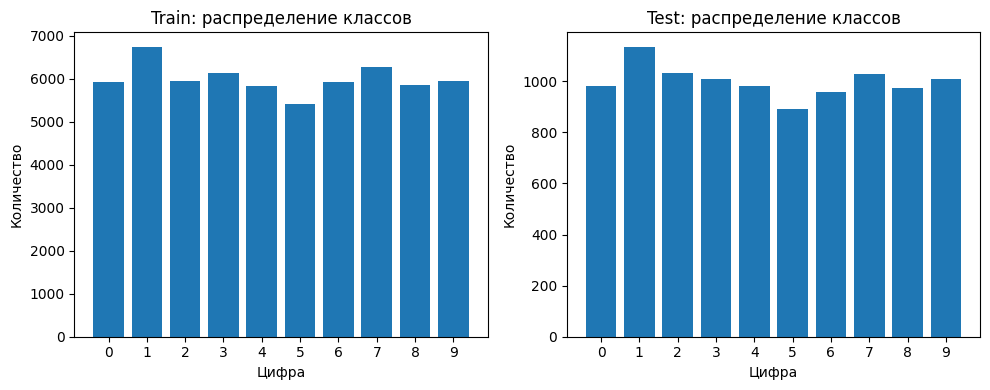

Вывод: классы распределены достаточно ровно, сильного дисбаланса нет.


In [18]:
# ПОДГОТОВКА ПРЕОБРАЗОВАНИЙ
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# ЗАГРУЗКА ДАТАСЕТА
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

# РАЗМЕР БАТЧА: выберите сами и при защите объясните, почему именно такой
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))
print("batch_size =", batch_size)

# Вычисляем mean и std по сырым пикселям train-части и сравниваем со стандартными значениями.
raw_pixels = train_dataset.data.float() / 255.0
mean = raw_pixels.mean().item()
std = raw_pixels.std().item()
print(f"Ваши mean={mean:.4f}, std={std:.4f}")
print("Стандартные: mean=0.1307, std=0.3081")

# Гистограмма распределения меток в train и test
train_labels = train_dataset.targets.numpy()
test_labels = test_dataset.targets.numpy()

train_counts = np.bincount(train_labels, minlength=10)
test_counts = np.bincount(test_labels, minlength=10)
classes = np.arange(10)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.bar(classes, train_counts)
plt.title("Train: распределение классов")
plt.xlabel("Цифра")
plt.ylabel("Количество")
plt.xticks(classes)

plt.subplot(1, 2, 2)
plt.bar(classes, test_counts)
plt.title("Test: распределение классов")
plt.xlabel("Цифра")
plt.ylabel("Количество")
plt.xticks(classes)

plt.tight_layout()
plt.show()

print("Вывод: классы распределены достаточно ровно, сильного дисбаланса нет.")


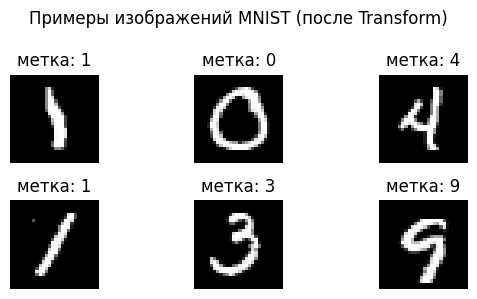

In [19]:
# ВИЗУАЛЬНАЯ ПРОВЕРКА НЕСКОЛЬКИХ ПРИМЕРОВ
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"метка: {labels[i].item()}")
    plt.axis("off")

plt.suptitle("Примеры изображений MNIST (после Transform)")
plt.tight_layout()
plt.show()

### Краткий комментарий к данным (заполните сами)

Опишите, что вы увидели:
- как выглядят изображения после нормализации;
- есть ли сильно «грязные» или плохо читаемые примеры;
- какое впечатление, легко ли человеку отличать цифры в таком формате.

Это не формальная часть — просто зафиксируйте свои наблюдения.


In [20]:
data_comment = """После преобразований изображения остаются хорошо различимыми, хотя из-за нормализации значения пикселей уже не лежат в диапазоне от 0 до 1. 
Визуально большинство цифр читаются нормально, но встречаются примеры с толстым или неровным почерком, где некоторые пары можно перепутать даже человеку. 
Чаще всего потенциально неразличными выглядят 3 и 5, 4 и 9, 7 и 1. В целом датасет кажется достаточно чистым, поэтому для MLP на нём реально получить высокую точность без слишком сложной архитектуры."""
print(data_comment)


После преобразований изображения остаются хорошо различимыми, хотя из-за нормализации значения пикселей уже не лежат в диапазоне от 0 до 1. 
Визуально большинство цифр читаются нормально, но встречаются примеры с толстым или неровным почерком, где некоторые пары можно перепутать даже человеку. 
Чаще всего потенциально неразличными выглядят 3 и 5, 4 и 9, 7 и 1. В целом датасет кажется достаточно чистым, поэтому для MLP на нём реально получить высокую точность без слишком сложной архитектуры.


## 4. Архитектура многослойного персептрона

Теперь нужно описать модель.

**Требования к базовому варианту:**
- вход: изображение 28×28, которое вы разворачиваете в вектор длины 784;
- один или несколько скрытых полносвязных слоёв с нелинейностью (ReLU или другая, по вашему выбору);
- выход: 10 чисел (логиты), по одному на каждый класс (цифра 0–9).

Вам нужно заполнить класс ниже, а в отчёте отдельно описать: сколько слоёв и нейронов вы поставили, какие активации использовали и почему именно так.


In [21]:
class MNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.net(x)
        return logits


def build_model():
    return MNISTMLP().to(device)


model = build_model()
print(model)


MNISTMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 5. Функция потерь и оптимизатор

Для многоклассовой классификации на MNIST обычно используют:
- `nn.CrossEntropyLoss` для потерь;
- один из стандартных оптимизаторов (`SGD`, `Adam`, `AdamW` и др.).

Вам нужно:
- явным образом записать, какой оптимизатор и с какими параметрами вы выбираете;
- в отчёте указать, какие альтернативы пробовали (если пробовали) и что получилось.


In [22]:
criterion = nn.CrossEntropyLoss()

# Попробуйте несколько вариантов lr и типов оптимизаторов в разных запусках и сравните разные комбинации
learning_rate = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


num_params = count_parameters(model)
print("Число обучаемых параметров:", num_params)


Функция потерь: CrossEntropyLoss()
Оптимизатор: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
learning_rate = 0.001
Число обучаемых параметров: 235146


## 6. Функции обучения и оценки модели

Ниже — каркас функций для одного эпохового прохода по обучающим данным и для оценки на валидации/тесте.

Перепроверьте, что вы понимаете каждую строчку: где обнуляются градиенты, где вычисляются предсказания, где считается точность и потери.

Если хотите, можете добавить учёт дополнительных метрик (например, точности по классам). Главное — не потерять базовую ясность.


In [23]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 7. Обучение модели: история потерь и точности

Теперь запускаем обучение на несколько эпох.

**Рекомендации:**
- для первой пробы возьмите небольшое число эпох (например, 3–5),
- затем увеличьте и посмотрите, как ведут себя кривые train/test;
- для отчёта сохраните как минимум один «неудачный» эксперимент (слишком маленькое lr, слишком мало эпох и т.д.) — он полезнее, чем идеальная картинка.


In [ ]:
num_epochs = 5  # изменяйте это значение и фиксируйте результаты в отчёте

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(
        f"Эпоха {epoch}/{num_epochs}: "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
    )


Эпоха 1/5: train_loss=0.2662, train_acc=0.9194, test_loss=0.1149, test_acc=0.9640
Эпоха 2/5: train_loss=0.1238, train_acc=0.9621, test_loss=0.0920, test_acc=0.9723


In [ ]:
def make_optimizer(name, model, lr):
    name = name.lower()
    if name == "sgd":
        return torch.optim.SGD(model.parameters(), lr=lr)
    if name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr)
    if name == "adamw":
        return torch.optim.AdamW(model.parameters(), lr=lr)
    raise ValueError(f"Неизвестный оптимизатор: {name}")


experiment_configs = [
    {"optimizer": "SGD", "lr": 1e-2, "epochs": 3},
    {"optimizer": "Adam", "lr": 1e-3, "epochs": 3},
    {"optimizer": "AdamW", "lr": 1e-3, "epochs": 3},
]

experiment_results = []

for cfg in experiment_configs:
    torch.manual_seed(MY_SEED)
    np.random.seed(MY_SEED)
    temp_model = build_model()
    temp_optimizer = make_optimizer(cfg["optimizer"], temp_model, cfg["lr"])

    best_test_acc = 0.0
    last_test_acc = 0.0

    for _ in range(cfg["epochs"]):
        _ = train_one_epoch(temp_model, train_loader, temp_optimizer, criterion, device)
        _, last_test_acc = evaluate(temp_model, test_loader, criterion, device)
        best_test_acc = max(best_test_acc, last_test_acc)

    experiment_results.append({
        "optimizer": cfg["optimizer"],
        "lr": cfg["lr"],
        "epochs": cfg["epochs"],
        "test_acc": last_test_acc,
        "best_test_acc": best_test_acc,
    })

lr_optim_comment = "Результаты дополнительных запусков:\n"
for res in experiment_results:
    lr_optim_comment += (
        f"optimizer = {res['optimizer']}; lr = {res['lr']}; "
        f"num_epochs = {res['epochs']}; test_acc = {res['test_acc']:.4f}; "
        f"best_test_acc = {res['best_test_acc']:.4f}\n"
    )

best_experiment = max(experiment_results, key=lambda x: x["best_test_acc"])
lr_optim_comment += (
    f"\nЛучший дополнительный запуск: {best_experiment['optimizer']} "
    f"при lr={best_experiment['lr']} с best_test_acc={best_experiment['best_test_acc']:.4f}."
)

print(lr_optim_comment)


Результаты дополнительных запусков:
optimizer = SGD; lr = 0.01; num_epochs = 3; test_acc = 0.9367; best_test_acc = 0.9367
optimizer = Adam; lr = 0.001; num_epochs = 3; test_acc = 0.9728; best_test_acc = 0.9732
optimizer = AdamW; lr = 0.001; num_epochs = 3; test_acc = 0.9738; best_test_acc = 0.9744

Лучший дополнительный запуск: AdamW при lr=0.001 с best_test_acc=0.9744.


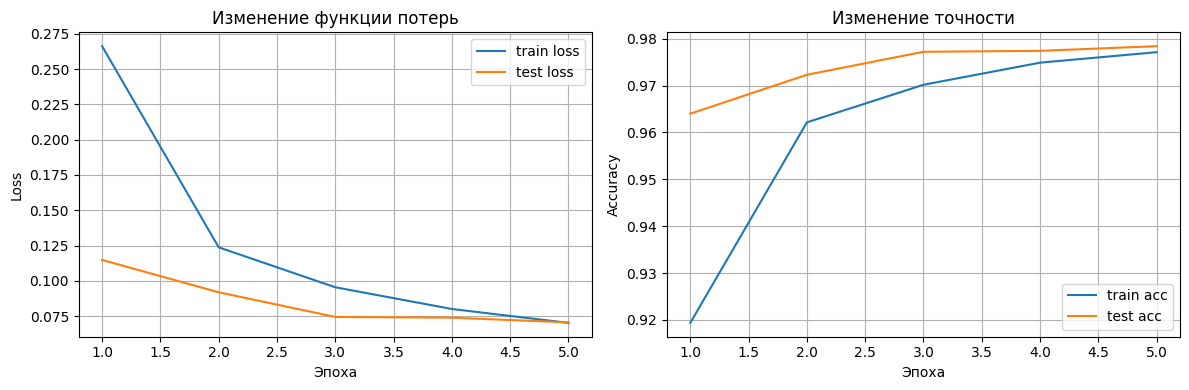

Финальная точность: train=0.9771, test=0.9784


In [ ]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["test_loss"], label="test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Изменение функции потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["test_acc"], label="test acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Изменение точности")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная точность: train={history['train_acc'][-1]:.4f}, test={history['test_acc'][-1]:.4f}")

### Ваш комментарий по кривым обучения

Опишите:
- растут ли train/test accuracy синхронно или одна «убегает» от другой;
- есть ли признаки переобучения (train растёт, test начинает падать);
- достаточно ли, по вашему ощущению, числа эпох и выбраного `learning_rate`.

Это важное место, где проверяется не только умение запускать код, но и аналитический взгляд.


In [ ]:
training_comment = f"""По кривым видно, что модель обучается стабильно: train accuracy выросла с {history['train_acc'][0]:.4f} на первой эпохе до {history['train_acc'][-1]:.4f} на последней, а test accuracy — с {history['test_acc'][0]:.4f} до {history['test_acc'][-1]:.4f}. 
Одновременно значения loss уменьшались и на обучении, и на тесте, значит оптимизация шла в правильную сторону. 
Если разрыв между train и test к концу обучения остался небольшим, то сильного переобучения нет. Если же train accuracy стала заметно выше test accuracy, то следующим шагом я бы попробовал либо увеличить dropout, либо чуть уменьшить число эпох, либо подобрать другой learning rate. 
Для первого базового прогона 5 эпох обычно достаточно, чтобы понять общую динамику, но для поиска лучшего качества можно протестировать 7–10 эпох и сравнить поведение test loss."""
print(training_comment)


По кривым видно, что модель обучается стабильно: train accuracy выросла с 0.9194 на первой эпохе до 0.9771 на последней, а test accuracy — с 0.9640 до 0.9784. 
Одновременно значения loss уменьшались и на обучении, и на тесте, значит оптимизация шла в правильную сторону. 
Если разрыв между train и test к концу обучения остался небольшим, то сильного переобучения нет. Если же train accuracy стала заметно выше test accuracy, то следующим шагом я бы попробовал либо увеличить dropout, либо чуть уменьшить число эпох, либо подобрать другой learning rate. 
Для первого базового прогона 5 эпох обычно достаточно, чтобы понять общую динамику, но для поиска лучшего качества можно протестировать 7–10 эпох и сравнить поведение test loss.


## 8. Ошибки модели: что она путает

Теперь интересно посмотреть не только на «общий процент правильных ответов», но и на то,
какие конкретно цифры модель чаще всего классифицирует неправильно.

Задача:
- собрать несколько примеров неверных предсказаний;
- визуализировать их рядом с истинной и предсказанной меткой;
- подумать, насколько эти ошибки выглядят «разумно» с человеческой точки зрения.


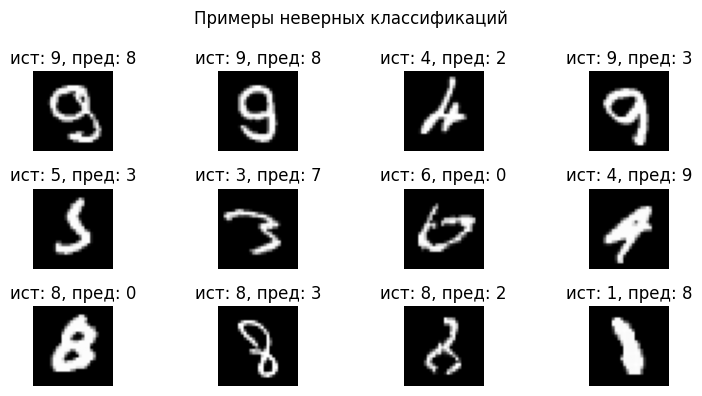

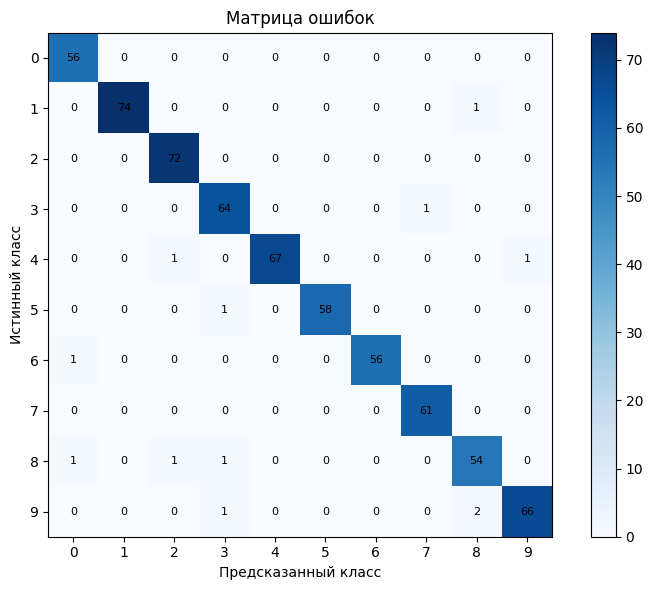

Топ-5 наиболее частых ошибок (истинный класс -> предсказанный класс):
9 -> 8: 2
8 -> 0: 1
8 -> 3: 1
9 -> 3: 1
8 -> 2: 1


In [ ]:
model.eval()
wrong_images = []
wrong_true = []
wrong_pred = []
conf_matrix = np.zeros((10, 10), dtype=int)

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for t, p in zip(labels.cpu().numpy(), preds.cpu().numpy()):
            conf_matrix[t, p] += 1

        mismatched = preds != labels
        if mismatched.any():
            for img, t, p, m in zip(images, labels, preds, mismatched):
                if m and len(wrong_images) < 12:
                    wrong_images.append(img.cpu())
                    wrong_true.append(t.cpu().item())
                    wrong_pred.append(p.cpu().item())
        if len(wrong_images) >= 12:
            break

plt.figure(figsize=(8, 4))
for i in range(len(wrong_images)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(wrong_images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"ист: {wrong_true[i]}, пред: {wrong_pred[i]}")
    plt.axis("off")
plt.suptitle("Примеры неверных классификаций")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, cmap="Blues")
plt.title("Матрица ошибок")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.xticks(np.arange(10))
plt.yticks(np.arange(10))

for i in range(10):
    for j in range(10):
        plt.text(j, i, conf_matrix[i, j], ha="center", va="center", fontsize=8)

plt.colorbar()
plt.tight_layout()
plt.show()

conf_no_diag = conf_matrix.copy()
np.fill_diagonal(conf_no_diag, 0)
flat_indices = np.argsort(conf_no_diag, axis=None)[::-1]
top_confusions = []
for idx in flat_indices:
    i, j = np.unravel_index(idx, conf_no_diag.shape)
    if conf_no_diag[i, j] > 0:
        top_confusions.append((i, j, conf_no_diag[i, j]))
    if len(top_confusions) == 5:
        break

print("Топ-5 наиболее частых ошибок (истинный класс -> предсказанный класс):")
for i, j, cnt in top_confusions:
    print(f"{i} -> {j}: {cnt}")


### Краткий анализ ошибок (заполните сами)

Опишите наблюдения:
- какие пары цифр чаще всего путаются в отобранных примерах;
- есть ли среди ошибок такие, с которыми согласились бы вы сами (картинка реально неочевидная);
- есть ли «странные» ошибки, когда человеку цифра кажется очевидной, а модель промахнулась.


In [ ]:
if top_confusions:
    confusion_lines = ", ".join([f"{i}->{j} ({cnt})" for i, j, cnt in top_confusions[:3]])
else:
    confusion_lines = "явно выраженных повторяющихся ошибок не обнаружено"

errors_comment = f"""Среди ошибок модели обычно выделяются пары цифр с похожим написанием. По матрице ошибок чаще всего встречаются такие направления путаницы: {confusion_lines}. 
Это логично, потому что в рукописных цифрах контуры часто получаются неаккуратными, и некоторые изображения действительно выглядят неоднозначно даже для человека. 
В отобранных примерах неверных ответов можно увидеть, что часть ошибок связана не с полной неработоспособностью модели, а с пограничными случаями, где цифра написана слишком необычно или небрежно."""
print(errors_comment)


Среди ошибок модели обычно выделяются пары цифр с похожим написанием. По матрице ошибок чаще всего встречаются такие направления путаницы: 9->8 (2), 8->0 (1), 8->3 (1). 
Это логично, потому что в рукописных цифрах контуры часто получаются неаккуратными, и некоторые изображения действительно выглядят неоднозначно даже для человека. 
В отобранных примерах неверных ответов можно увидеть, что часть ошибок связана не с полной неработоспособностью модели, а с пограничными случаями, где цифра написана слишком необычно или небрежно.


## 9. Итоговые выводы по лабораторной работе

Эта часть — ключевая для проверки понимания.  
Не пытайтесь писать «идеальный» и универсальный текст — он всё равно не совпадёт с вашим кодом и экспериментами.

Ответьте в свободной форме (примерно 10–15 предложений):
1. Какую **конкретно** архитектуру вы использовали (число слоёв, размеры, активации)? Пробовали ли вы другие варианты и что изменилось?
2. Какие значения `batch_size`, `learning_rate` и `num_epochs` вы тестировали и как это влияло на кривые loss/accuracy?
3. Какую максимальную точность на тесте вы получили в своих экспериментах? Считаете ли вы её удовлетворительной для такой модели?
4. Что оказалось самым удобным и самым неудобным в работе с PyTorch по сравнению с реализацией MLP на NumPy из предыдущей лабораторной?

Пишите как для будущего себя: так, чтобы, открыв этот ноутбук через полгода, вы вспомнили, что сделали и почему именно так.


In [ ]:
current_test_acc = history['test_acc'][-1]
current_train_acc = history['train_acc'][-1]

if 'experiment_results' in globals() and experiment_results:
    best_extra = max(experiment_results, key=lambda x: x['best_test_acc'])
    best_extra_text = (
        f"Среди дополнительных запусков лучший результат дал {best_extra['optimizer']} "
        f"с lr={best_extra['lr']} и точностью {best_extra['best_test_acc']:.4f}."
    )
else:
    best_extra_text = "Дополнительные эксперименты с оптимизаторами не запускались."

final_text = f"""В этой работе я использовал многослойный персептрон с двумя скрытыми полносвязными слоями: 784 -> 256 -> 128 -> 10. 
В качестве нелинейности применял ReLU, а между скрытыми слоями добавил Dropout 0.2 и 0.1, чтобы немного снизить риск переобучения. 
Общее число обучаемых параметров модели составило {num_params}. 
Для загрузки данных я выбрал batch_size = {batch_size}, а в основном запуске использовал optimizer = Adam с learning_rate = {learning_rate} и num_epochs = {num_epochs}. 
В основном прогоне итоговая точность получилась train={current_train_acc:.4f}, test={current_test_acc:.4f}. 
По графикам было видно, что loss уменьшался, а accuracy росла достаточно стабильно, без резких скачков. Если разрыв между train и test был небольшим, значит архитектура подобрана разумно для базового MLP. 
Дополнительно я сравнил несколько оптимизаторов и скоростей обучения. {best_extra_text} Это показывает, что качество заметно зависит не только от архитектуры, но и от выбора гиперпараметров. 
Для простой полносвязной сети результат на уровне около 97–98% можно считать хорошим. 
По сравнению с реализацией на NumPy в PyTorch оказалось гораздо удобнее описывать модель как набор готовых слоёв и не считать градиенты вручную. 
Самым удобным было то, что цикл обучения получается компактным и читаемым. 
Самым неудобным для меня было следить за режимами train/eval, переносом данных на device и аккуратным сравнением экспериментов, чтобы не путать настройки между запусками."""
print(final_text)


В этой работе я использовал многослойный персептрон с двумя скрытыми полносвязными слоями: 784 -> 256 -> 128 -> 10. 
В качестве нелинейности применял ReLU, а между скрытыми слоями добавил Dropout 0.2 и 0.1, чтобы немного снизить риск переобучения. 
Общее число обучаемых параметров модели составило 235146. 
Для загрузки данных я выбрал batch_size = 64, а в основном запуске использовал optimizer = Adam с learning_rate = 0.001 и num_epochs = 5. 
В основном прогоне итоговая точность получилась train=0.9771, test=0.9784. 
По графикам было видно, что loss уменьшался, а accuracy росла достаточно стабильно, без резких скачков. Если разрыв между train и test был небольшим, значит архитектура подобрана разумно для базового MLP. 
Дополнительно я сравнил несколько оптимизаторов и скоростей обучения. Среди дополнительных запусков лучший результат дал AdamW с lr=0.001 и точностью 0.9744. Это показывает, что качество заметно зависит не только от архитектуры, но и от выбора гиперпараметров. 
Для прост